1) Setup and helpers

In [1]:
import re
import pandas as pd
from pathlib import Path

ROOT = Path(".").resolve()
CLIENT_LOG = ROOT / "esp_client.log"
SERVER_LOG = ROOT / "server.log"

2) Parse ESP32 CSTATS log

In [2]:
def load_client_log(path=CLIENT_LOG):
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("CSTATS;"):
                continue
            parts = line.split(";")
            if len(parts) != 9:
                continue
            _, ms_since_start, recv_pkts, inflight, rtt_us, jitter_us, win, burst, rate_Bps = parts
            rows.append({
                "t_client_ms": int(ms_since_start),
                "recv_pkts": int(recv_pkts),
                "inflight": int(inflight),
                "rtt_us": int(rtt_us),
                "jitter_us": int(jitter_us),
                "win": int(win),
                "burst": int(burst),
                "rate_Bps": int(rate_Bps),
            })
    df = pd.DataFrame(rows).sort_values("t_client_ms")
    df["t_client_s"] = df["t_client_ms"] / 1000.0
    return df

df_client = load_client_log()
df_client.head()

,t_client_ms,recv_pkts,inflight,rtt_us,jitter_us,win,burst,rate_Bps,t_client_s
0,148,1,11,0,0,3,1,13721,0.148
1,152,2,10,0,0,3,1,18802,0.152
2,163,3,9,0,0,3,1,23983,0.163
3,172,4,8,0,0,3,1,28511,0.172
4,180,5,7,0,0,4,1,32581,0.180


3) Parse server.log

In [3]:
import re
import pandas as pd

server_re = re.compile(
    r"""
    ^\[RECVER\]:\s+                                 # prefixo
    (?P<t_server_s>[\d\.]+)\s+sec,\s+               # tempo em segundos
    Rcvd:\s+(?P<rcvd_mbps>[\d\.]+)\s+Mbps,\s+       # taxa recebida
    Sent:\s+(?P<sent_mbps>[\d\.]+)\s+Mbps,\s+       # taxa enviada
    RTT:\s+(?P<rtt_ms>[\d\.]+)\s+ms,\s+             # RTT em ms
    Mark:\s+(?P<mark_prob>[\d\.]+)%\((?P<pkt_mark>\d+)/\d+\),\s+  # ECN
    Lost:\s+(?P<loss_prob>[-\d\.]+)%\((?P<pkt_lost>\d+)/\d+\)     # perdas
    """,
    re.VERBOSE,
)

def load_server_log(path=SERVER_LOG, pattern=server_re):
    rows = []
    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue
            d = m.groupdict()
            rows.append({
                "t_server_s": float(d["t_server_s"]),
                "rcvd_rate_mbps": float(d["rcvd_mbps"]),
                "sent_rate_mbps": float(d["sent_mbps"]),
                "rtt_ms": float(d["rtt_ms"]),
                "mark_prob_percent": float(d["mark_prob"]),
                "pkt_mark": int(d["pkt_mark"]),
                "loss_prob_percent": float(d["loss_prob"]),
                "pkt_lost": int(d["pkt_lost"]),
            })
    df = pd.DataFrame(rows).sort_values("t_server_s")
    return df

df_server = load_server_log()
df_server.head()

,t_server_s,rcvd_rate_mbps,sent_rate_mbps,rtt_ms,mark_prob_percent,pkt_mark,loss_prob_percent,pkt_lost
0,8.96,0.000,0.000,0.000,0.0,0,0.0,0
1,9.98,0.005,0.011,9624.086,0.0,0,0.0,0
2,10.99,0.008,0.015,10487.509,0.0,0,0.0,0
3,12.01,0.007,0.015,11499.709,0.0,0,0.0,0
4,13.02,0.008,0.015,12508.403,0.0,0,0.0,0


4) Time alignment and merged view

In [4]:
# alinhamento simples no tempo
df_client["t_round"] = df_client["t_client_s"].round(3)
df_server["t_round"] = df_server["t_server_s"].round(3)

df_join = pd.merge_asof(
    df_client.sort_values("t_round"),
    df_server.sort_values("t_round"),
    on="t_round",
    direction="nearest",
    tolerance=0.05,  # 50 ms
)

df_join.head()

,t_client_ms,recv_pkts,inflight,rtt_us,jitter_us,win,burst,rate_Bps,t_client_s,t_round,t_server_s,rcvd_rate_mbps,sent_rate_mbps,rtt_ms,mark_prob_percent,pkt_mark,loss_prob_percent,pkt_lost
0,148,1,11,0,0,3,1,13721,0.148,0.148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,152,2,10,0,0,3,1,18802,0.152,0.152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,163,3,9,0,0,3,1,23983,0.163,0.163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,172,4,8,0,0,3,1,28511,0.172,0.172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,180,5,7,0,0,4,1,32581,0.180,0.180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5) Quick plots

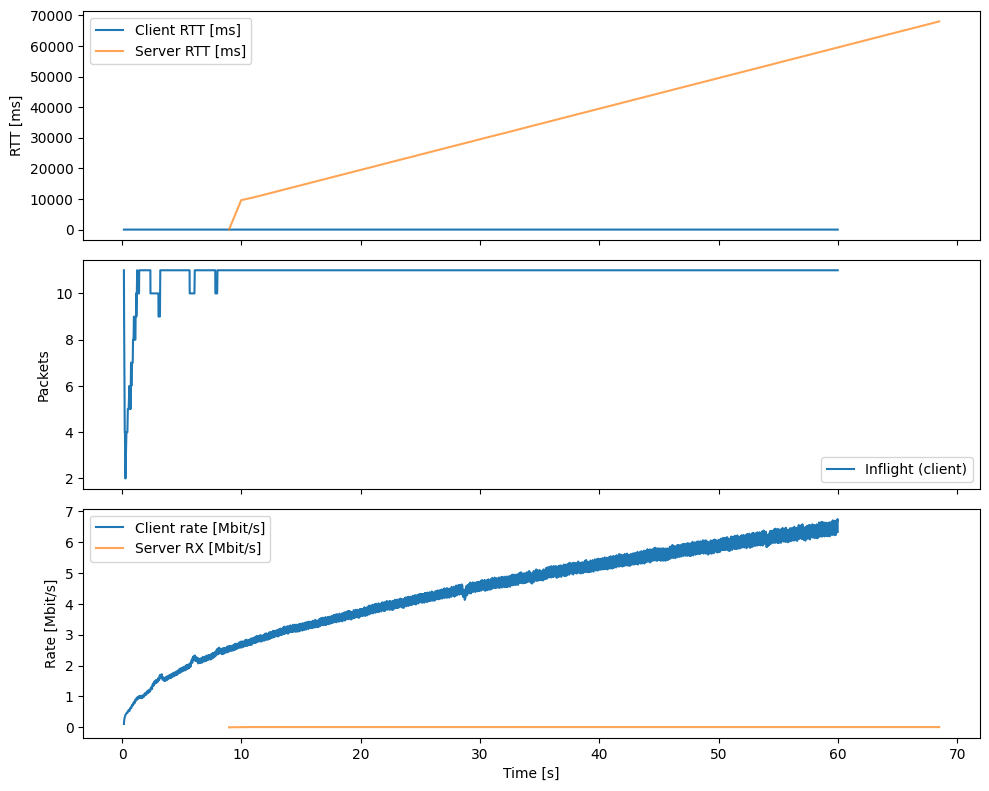

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(df_client["t_client_s"], df_client["rtt_us"] / 1000.0, label="Client RTT [ms]")
axes[0].plot(df_server["t_server_s"], df_server["rtt_ms"], label="Server RTT [ms]", alpha=0.7)
axes[0].set_ylabel("RTT [ms]"); axes[0].legend()

axes[1].plot(df_client["t_client_s"], df_client["inflight"], label="Inflight (client)")
axes[1].set_ylabel("Packets"); axes[1].legend()

axes[2].plot(df_client["t_client_s"], df_client["rate_Bps"] * 8 / 1e6, label="Client rate [Mbit/s]")
axes[2].plot(df_server["t_server_s"], df_server["rcvd_rate_mbps"], label="Server RX [Mbit/s]", alpha=0.7)
axes[2].set_ylabel("Rate [Mbit/s]"); axes[2].set_xlabel("Time [s]"); axes[2].legend()

plt.tight_layout()
plt.show()

fig.savefig("prague_client_server_timeseries.png", dpi=300, bbox_inches="tight")

#### Tests

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re


def parse_server_log(log_file):
    """Parse server log - correct [RECVER] format"""
    data = {
        'time_sec': [],
        'rcvd_rate_mbps': [],
        'sent_rate_mbps': [],
        'rtt_ms': [],
        'mark_prob_percent': [],
        'pkt_mark': [],
        'pkt_mark_total': [],
        'loss_prob_percent': [],
        'pkt_lost': [],
        'pkt_loss_total': [],
    }

    with open(log_file, 'r') as f:
        for line in f:
            if '[RECVER]:' not in line:
                continue

            try:
                # Time
                match_ts = re.search(r'(\d+\.\d+)\s+sec', line)
                if not match_ts:
                    continue
                time_sec = float(match_ts.group(1))

                # RX/TX rates
                match_rates = re.search(
                    r'Rcvd:\s+([\d.]+)\s+Mbps.*?Sent:\s+([\d.]+)\s+Mbps',
                    line
                )
                if not match_rates:
                    continue
                rcvd = float(match_rates.group(1))
                sent = float(match_rates.group(2))

                # RTT
                match_rtt = re.search(r'RTT:\s+([\d.]+)\s+ms', line)
                rtt = float(match_rtt.group(1)) if match_rtt else 0.0

                # ECN (marking)
                match_mark = re.search(r'Mark:\s+([\d.]+)%\((\d+)/(\d+)\)', line)
                if match_mark:
                    mark_prob = float(match_mark.group(1))
                    pkt_mark = int(match_mark.group(2))
                    pkt_mark_total = int(match_mark.group(3))
                else:
                    mark_prob = 0.0
                    pkt_mark = 0
                    pkt_mark_total = 0

                # Loss
                match_loss = re.search(r'Lost:\s+([-?\d.]+)%\((\d+)/(\d+)\)', line)
                if match_loss:
                    loss_prob = float(match_loss.group(1))
                    pkt_lost = int(match_loss.group(2))
                    pkt_loss_total = int(match_loss.group(3))
                else:
                    loss_prob = 0.0
                    pkt_lost = 0
                    pkt_loss_total = 0

                data['time_sec'].append(time_sec)
                data['rcvd_rate_mbps'].append(rcvd)
                data['sent_rate_mbps'].append(sent)
                data['rtt_ms'].append(rtt)
                data['mark_prob_percent'].append(mark_prob)
                data['pkt_mark'].append(pkt_mark)
                data['pkt_mark_total'].append(pkt_mark_total)
                data['loss_prob_percent'].append(loss_prob)
                data['pkt_lost'].append(pkt_lost)
                data['pkt_loss_total'].append(pkt_loss_total)

            except Exception:
                continue

    return pd.DataFrame(data)


def calculate_derived_metrics(df):
    """Calculate derived metrics from server data"""

    window = 10

    # 1. RTT jitter (moving window)
    df['rtt_jitter_ms'] = df['rtt_ms'].rolling(window=window, center=True).std()

    # 2. RTT Min/Max ratio
    df['rtt_min_window'] = df['rtt_ms'].rolling(window=window, center=True).min()
    df['rtt_max_window'] = df['rtt_ms'].rolling(window=window, center=True).max()
    df['rtt_minmax_ratio'] = df['rtt_max_window'] / (df['rtt_min_window'] + 1e-6)

    # 3. Goodput (RX/TX efficiency)
    df['goodput'] = df['rcvd_rate_mbps'] / (df['sent_rate_mbps'] + 1e-6)

    # 4. Throughput variance (stability)
    df['rcvd_variance'] = df['rcvd_rate_mbps'].rolling(window=window, center=True).std()
    df['rcvd_cv'] = df['rcvd_variance'] / (df['rcvd_rate_mbps'] + 1e-6) * 100

    # 5. RTT growth rate d(RTT)/dt
    df['rtt_growth_rate'] = df['rtt_ms'].diff() / df['time_sec'].diff()

    # 6. Cumulative loss metrics (using Lost denominator)
    df['total_pkt_sent_cum'] = df['pkt_loss_total'].cumsum()
    df['total_pkt_lost_cum'] = df['pkt_lost'].cumsum()
    df['cumulative_loss_rate'] = (
        df['total_pkt_lost_cum'] / (df['total_pkt_sent_cum'] + 1e-6) * 100
)

    # 7. Estimated buffer depth (BDP)
    df['buffer_depth_bytes'] = (df['rcvd_rate_mbps'] * df['rtt_ms'] / 1000) / 8 * 1e6

    # 8. ECN efficiency (using Mark denominator)
    df['total_pkt_recv_cum'] = df['pkt_mark_total'].cumsum()
    df['total_pkt_mark_cum'] = df['pkt_mark'].cumsum()
    df['ecn_efficiency'] = (
        df['total_pkt_mark_cum'] / (df['total_pkt_recv_cum'] + 1e-6) * 100
)

    # 9. Retransmission estimate (kbps)
    df['retransmission_rate_kbps'] = (
        df['rcvd_rate_mbps'] * df['loss_prob_percent'] / 100 * 1000
)

    # 10. Network Quality Index (heuristic 0–100)
    rtt_score = 100 - np.clip(
        (df['rtt_jitter_ms'] / (df['rtt_ms'].max() + 1e-6)) * 100, 0, 100
)
    loss_score = 100 - np.clip(df['loss_prob_percent'] * 10, 0, 100)
    ecn_score = np.clip(df['mark_prob_percent'] * 2, 0, 100)

    df['network_quality_index'] = (rtt_score + loss_score + ecn_score) / 3

    return df


def create_enhanced_report(df, output_file='prague_performance_enhanced.png'):
    """Create visual report with 8 plots"""

    if df.empty:
        print("Dataframe is empty")
        return

    fig = plt.figure(figsize=(22, 16))
    gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

    # 1. RTT + Jitter
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(df['time_sec'], df['rtt_ms'],
             color='#2E86AB', linewidth=2.5,
             label='RTT', marker='o', markersize=2, markevery=15)
    ax1.fill_between(df['time_sec'], df['rtt_ms'], alpha=0.2, color='#2E86AB')

    ax1_twin = ax1.twinx()
    ax1_twin.plot(df['time_sec'], df['rtt_jitter_ms'],
                  color='#E74C3C', linewidth=1.5,
                  linestyle='--', label='Jitter (σ)', alpha=0.7)
    ax1_twin.set_ylabel('Jitter (ms)', fontsize=10, color='#E74C3C', fontweight='bold')

    ax1.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax1.set_ylabel('RTT (ms)', fontsize=10, fontweight='bold')
    ax1.set_title('RTT + Jitter Evolution', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor('#f8f9fa')
    ax1.legend(loc='upper left', fontsize=9)

    # 2. RTT Min/Max Ratio
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.fill_between(df['time_sec'], 1, df['rtt_minmax_ratio'],
                     alpha=0.4, color='#9B59B6', label='Max/Min Ratio')
    ax2.plot(df['time_sec'], df['rtt_minmax_ratio'],
             color='#8E44AD', linewidth=2.5,
             marker='d', markersize=3, markevery=15)
    ax2.axhline(y=1.2, color='green', linestyle='--',
                linewidth=2, alpha=0.7, label='Stable (<1.2)')
    ax2.axhline(y=1.5, color='orange', linestyle='--',
                linewidth=2, alpha=0.7, label='Moderate (<1.5)')

    ax2.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax2.set_ylabel('RTT Max/Min Ratio', fontsize=10, fontweight='bold')
    ax2.set_title('RTT Stability (Min/Max)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')
    ax2.legend(fontsize=9)

    # 3. Goodput
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(df['time_sec'], df['goodput'],
             color='#16A085', linewidth=2.5,
             label='Goodput Ratio', marker='s', markersize=3, markevery=15)
    ax3.axhline(y=1.0, color='red', linestyle='--',
                linewidth=2, alpha=0.7, label='Ideal (1.0)')
    ax3.fill_between(df['time_sec'], 0, df['goodput'],
                     alpha=0.2, color='#16A085')

    ax3.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax3.set_ylabel('RX / TX Ratio', fontsize=10, fontweight='bold')
    ax3.set_title('Goodput - Transfer Efficiency', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_facecolor('#f8f9fa')
    ax3.legend(fontsize=9)

    # 4. Throughput Coefficient of Variation
    ax4 = fig.add_subplot(gs[1, 1])
    colors_cv = [
        '#06A77D' if x < 5 else '#FFB703' if x < 10 else '#E74C3C'
        for x in df['rcvd_cv'].fillna(0)
    ]
    ax4.bar(df['time_sec'], df['rcvd_cv'].fillna(0),
            width=0.6, color=colors_cv,
            alpha=0.8, edgecolor='black', linewidth=0.5)
    ax4.axhline(y=5, color='green', linestyle='--',
                linewidth=2, alpha=0.7, label='Stable (<5%)')
    ax4.axhline(y=10, color='orange', linestyle='--',
                linewidth=2, alpha=0.7, label='Moderate (<10%)')

    ax4.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax4.set_ylabel('CV (%)', fontsize=10, fontweight='bold')
    ax4.set_title('RX Throughput Variance', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_facecolor('#f8f9fa')
    ax4.legend(fontsize=9)

    # 5. RTT Growth Rate
    ax5 = fig.add_subplot(gs[2, 0])
    rtt_growth = df['rtt_growth_rate'].fillna(0)
    colors_growth = ['#E74C3C' if x > 0 else '#06A77D' for x in rtt_growth]
    ax5.bar(df['time_sec'], rtt_growth,
            width=0.6, color=colors_growth,
            alpha=0.8, edgecolor='black', linewidth=0.5)
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)

    ax5.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax5.set_ylabel('d(RTT)/dt (ms/s)', fontsize=10, fontweight='bold')
    ax5.set_title('RTT Growth Rate (congestion detection)', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_facecolor('#f8f9fa')

    # 6. Cumulative Loss Rate
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(df['time_sec'], df['cumulative_loss_rate'],
             color='#E74C3C', linewidth=2.5,
             label='Cumulative Loss %', marker='o', markersize=2, markevery=15)
    ax6.fill_between(df['time_sec'], df['cumulative_loss_rate'],
                     alpha=0.2, color='#E74C3C')
    ax6.axhline(y=1.0, color='orange', linestyle='--',
                linewidth=2, alpha=0.7, label='1% Threshold')

    ax6.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax6.set_ylabel('Cumulative Loss Rate (%)', fontsize=10, fontweight='bold')
    ax6.set_title('Cumulative Loss Rate', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.set_facecolor('#f8f9fa')
    ax6.legend(fontsize=9)

    # 7. Buffer Depth (BDP)
    ax7 = fig.add_subplot(gs[3, 0])
    buffer_mb = df['buffer_depth_bytes'] / (1024 * 1024)
    ax7.fill_between(df['time_sec'], buffer_mb,
                     alpha=0.4, color='#3498DB',
                     label='Estimated Buffer Depth')
    ax7.plot(df['time_sec'], buffer_mb,
             color='#2980B9', linewidth=2.5,
             marker='s', markersize=3, markevery=15)

    ax7.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax7.set_ylabel('Buffer Depth (MB)', fontsize=10, fontweight='bold')
    ax7.set_title('Estimated Network Buffer Depth (BDP)', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    ax7.set_facecolor('#f8f9fa')

    # 8. Network Quality Index
    ax8 = fig.add_subplot(gs[3, 1])
    nqi = df['network_quality_index'].fillna(0)
    colors_nqi = [
        '#E74C3C' if x < 50 else '#FFB703' if x < 70 else '#06A77D'
        for x in nqi
    ]
    ax8.bar(df['time_sec'], nqi,
            width=0.6, color=colors_nqi,
            alpha=0.8, edgecolor='black', linewidth=0.5, label='NQI')
    ax8.axhline(y=70, color='green', linestyle='--',
                linewidth=2, alpha=0.7, label='Good (>70)')
    ax8.axhline(y=50, color='orange', linestyle='--',
                linewidth=2, alpha=0.7, label='Moderate (>50)')

    ax8.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    ax8.set_ylabel('Network Quality Index (0-100)', fontsize=10, fontweight='bold')
    ax8.set_title('Network Quality Index', fontsize=12, fontweight='bold')
    ax8.set_ylim(0, 100)
    ax8.grid(True, alpha=0.3, axis='y')
    ax8.set_facecolor('#f8f9fa')
    ax8.legend(fontsize=9)

    fig.suptitle(
        'Advanced Performance Analysis - Prague Congestion Control\n'
        'Server-Side Derived Metrics Only',
        fontsize=16, fontweight='bold', y=0.995
)

    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Advanced report saved to: {output_file}")
    plt.show()


def create_advanced_statistics(df, output_csv='prague_advanced_metrics.csv'):
    """Export advanced metrics to CSV and print summary"""

    stats = {
        'Metric': [
            '--- BASIC METRICS ---',
            'Test Duration (s)',
            'Average RTT (ms)',
            'Min RTT (ms)',
            'Max RTT (ms)',
            'RTT Standard Deviation (ms)',
            '',
            '--- DERIVED METRICS ---',
            'Average Jitter (σ RTT)',
            'Max Jitter',
            'Average RTT Max/Min Ratio',
            'RTT Stability (%)',
            '',
            '--- EFFICIENCY ---',
            'Average Goodput',
            'Min Goodput',
            'Max Goodput',
            'Average CV (%)',
            'Average RX Throughput (Mbps)',
            '',
            '--- LOSS & ECN ---',
            'Average Loss Rate (%)',
            'Max Loss Rate (%)',
            'Total Lost Packets',
            'Average ECN Rate (%)',
            'Max ECN Rate (%)',
            'Total ECN-Marked Packets',
            '',
            '--- NETWORK HEALTH ---',
            'Average Buffer Depth (MB)',
            'Max Buffer Depth (MB)',
            'Average RTT Growth Rate (ms/s)',
            'Average Retransmission Rate (Kbps)',
            'Average Network Quality Index',
            'Intervals with Good NQI (>70)',
            'Intervals with Moderate NQI (50-70)',
            'Intervals with Poor NQI (<50)',
        ],
        'Value': [
            '',
            f"{df['time_sec'].max():.2f}",
            f"{df['rtt_ms'].mean():.2f}",
            f"{df['rtt_ms'].min():.2f}",
            f"{df['rtt_ms'].max():.2f}",
            f"{df['rtt_ms'].std():.2f}",
            '',
            '',
            f"{df['rtt_jitter_ms'].mean():.2f}",
            f"{df['rtt_jitter_ms'].max():.2f}",
            f"{df['rtt_minmax_ratio'].mean():.2f}",
            f"{(100 - (df['rtt_jitter_ms'].mean() / (df['rtt_ms'].max() + 1e-6) * 100)):.1f}",
            '',
            '',
            f"{df['goodput'].mean():.4f}",
            f"{df['goodput'].min():.4f}",
            f"{df['goodput'].max():.4f}",
            f"{df['rcvd_cv'].mean():.2f}",
            f"{df['rcvd_rate_mbps'].mean():.4f}",
            '',
            '',
            f"{df['loss_prob_percent'].mean():.3f}",
            f"{df['loss_prob_percent'].max():.3f}",
            f"{df['pkt_lost'].sum():.0f}",
            f"{df['mark_prob_percent'].mean():.3f}",
            f"{df['mark_prob_percent'].max():.3f}",
            f"{df['pkt_mark'].sum():.0f}",
            '',
            '',
            f"{(df['buffer_depth_bytes'].mean() / (1024*1024)):.2f}",
            f"{(df['buffer_depth_bytes'].max() / (1024*1024)):.2f}",
            f"{df['rtt_growth_rate'].mean():.3f}",
            f"{df['retransmission_rate_kbps'].mean():.2f}",
            f"{df['network_quality_index'].mean():.1f}",
            f"{(df['network_quality_index'] > 70).sum()}",
            f"{((df['network_quality_index'] >= 50) & (df['network_quality_index'] <= 70)).sum()}",
            f"{(df['network_quality_index'] < 50).sum()}",
        ]
    }

    stats_df = pd.DataFrame(stats)
    stats_df.to_csv(output_csv, index=False)
    print(f"Advanced metrics saved to: {output_csv}")

    print("\n" + "=" * 70)
    print("FULL STATISTICAL SUMMARY")
    print("=" * 70)
    for _, row in stats_df.iterrows():
        if row['Metric'] == '':
            print()
        elif row['Metric'].startswith('---'):
            print(f"\n{row['Metric']}")
        else:
            print(f"{row['Metric']:.<50} {row['Value']:>17}")
    print("=" * 70 + "\n")

✅ 60 pontos de dados parseados
✅ Relatório avançado salvo em: prague_performance_enhanced.png
✅ Relatório avançado salvo em: prague_performance_enhanced.png


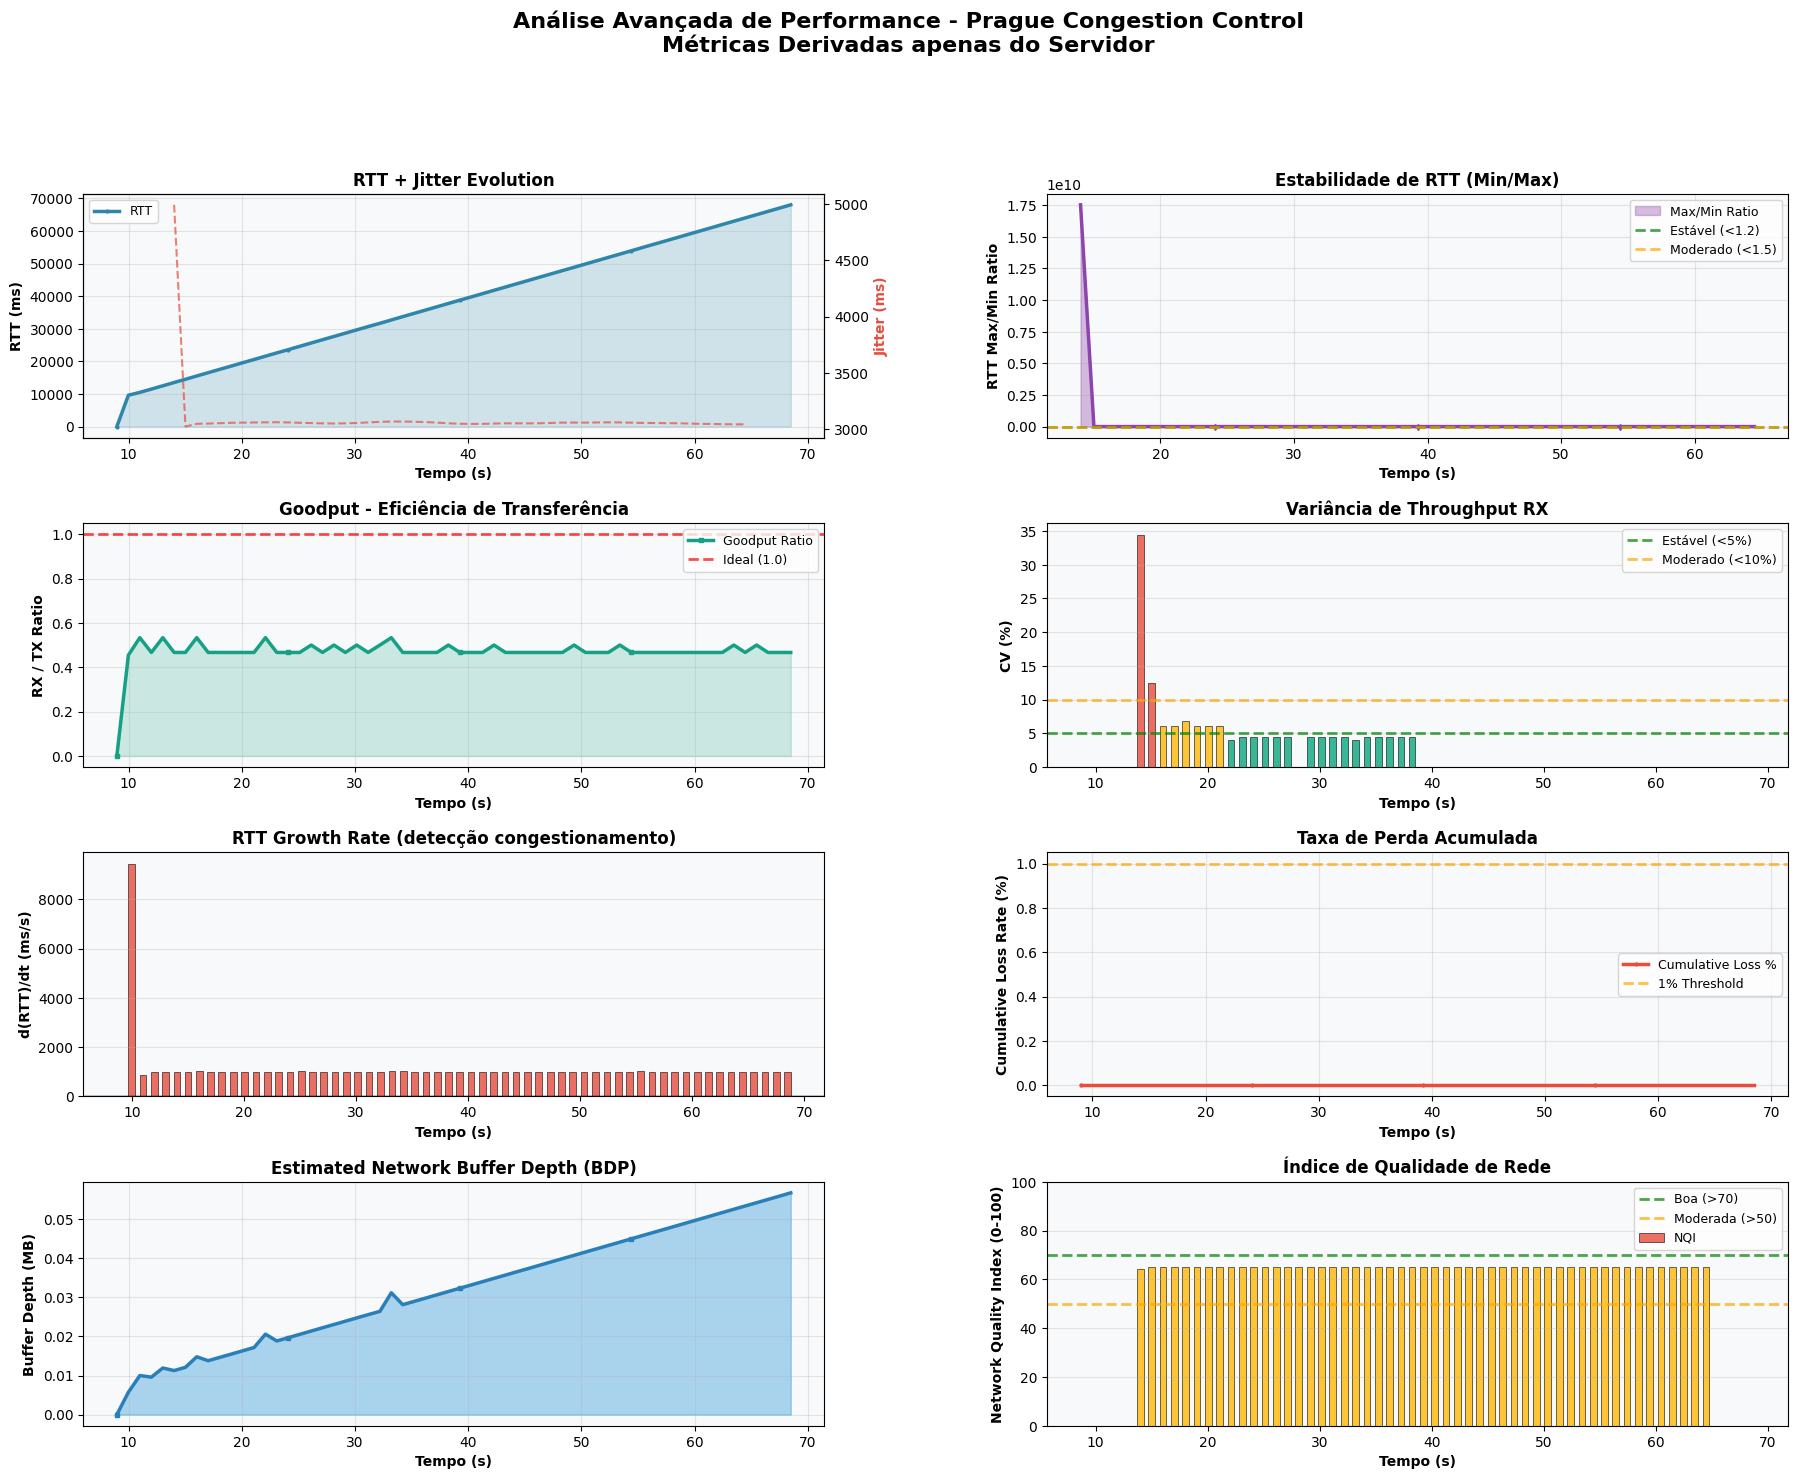

✅ Métricas avançadas salvas em: prague_advanced_metrics.csv

📊 RESUMO ESTATÍSTICO COMPLETO

--- BASIC METRICS ---
Duração do Teste (s)..............................             68.50
RTT Médio (ms)....................................          38108.37
RTT Min (ms)......................................              0.00
RTT Max (ms)......................................          68007.78
RTT Desvio Padrão (ms)............................          17901.49


--- DERIVED METRICS ---
Jitter Médio (σ RTT)..............................           3093.60
Jitter Máximo.....................................           4992.53
RTT Max/Min Ratio Médio...........................      343833903.27
Estabilidade RTT (%)..............................              95.5


--- EFFICIENCY ---
Goodput Médio.....................................            0.4698
Goodput Min.......................................            0.0000
Goodput Max.......................................            0.5333
Variance CV

In [ ]:
# Run advanced analysis directly in the notebook

log_file = "server.log"

output_image = "prague_performance_enhanced.png"

output_csv = "prague_advanced_metrics.csv"


df = parse_server_log(log_file)

if df.empty:

    print("No data found in server.log")

else:

    print(f"Parsed {len(df)} data points")

    df = calculate_derived_metrics(df)

    create_enhanced_report(df, output_image)

    create_advanced_statistics(df, output_csv)
